# Catching phishing from the link alone
### and why "99% accuracy" in URL phishing detection is mostly an illusion

*Data Science & Cyber course project. This is the **URL / link detector** — one half of a two-part
system (my partner built the text/content detector). It reads only the URL and decides phishing vs.
legitimate, and then I spend most of the effort showing that its near-perfect score is fragile.*

**The one-line story:** a simple model scores **F1 ≈ 1.0** on a modern public URL dataset — but that
number is a *collection artifact*. It comes from a single leaked feature and from HTTP-vs-HTTPS, it can
be evaded by trivially dressing a phishing URL up as a clean home-page, and on an **independent** dataset
it collapses to **AUC 0.43 — worse than a coin flip**. Structure alone is not a generalizable phishing
signal, which is exactly the argument for fusing it with the content channel.

Every number below is produced by `run_all.py` (deterministic, seed 42) and reloaded here.

In [1]:
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, "..")            # import the project's src package
from src import attacks, data, features

pd.set_option("display.max_colwidth", 70)


def T(name):
    # load a result table
    return pd.read_csv(f"../results/tables/{name}.csv")


def F(name):
    # show a result figure
    display(Image(f"../results/figures/{name}.png"))


print("helpers ready")

helpers ready


## 1. The data

**PhiUSIIL** (Prasad & Chandra, 2024; UCI ML Repository id 967) — **235,795 real URLs**, 134,850
legitimate and 100,945 phishing, each with the raw URL string. It is one of the largest and most recent
public URL datasets, which is exactly why its near-perfect benchmark scores are worth interrogating.

*Course link — EDA:* before any model, look at balance, shape, and the obvious signals.

235370 unique URLs | 42.7% phishing


,dataset,urls,phishing,legitimate,phishing_rate
0,PhiUSIIL,235370,100520,134850,0.427


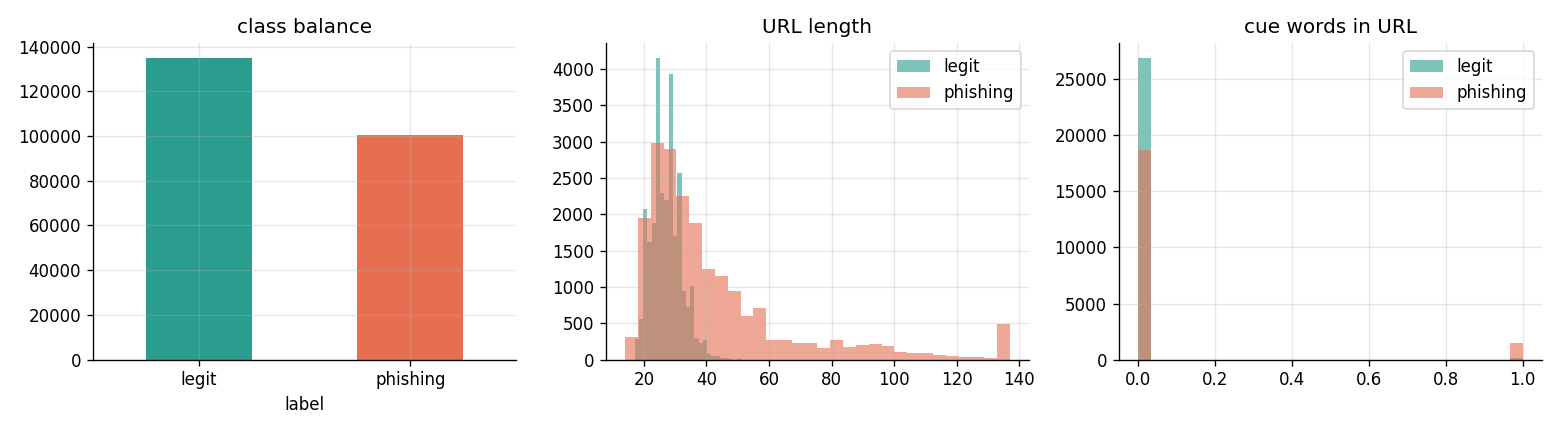

In [2]:
df = data.working_set(data.load_phiusiil())
print(len(df), "unique URLs |", f"{df.label.mean():.1%} phishing")
display(T("T1_dataset"))
F("F1_eda")

Already a red flag in the EDA figure: the two classes separate almost perfectly on trivial structural
quantities. That is *too* easy — real phishing and real legitimate URLs are not this cleanly divided.

## 2. Feature engineering — 40 signals from the URL string alone

*Course link — feature engineering, information theory, edit distance.* I compute everything from the
URL string (no network fetch), so the detector is fast, private and reproducible. Two features carry
real theory:

- **Shannon entropy** of the host, $H(s)=-\sum_i p_i\log_2 p_i$ — random-looking (algorithmically
  generated) domains score high.
- **Brand look-alike** = the **Levenshtein edit distance** from a domain label to a known brand
  (`paypa1`, `arnazon`), the classic typo-squat signal (Ma et al. 2009; Garera et al. 2007).

In [3]:
for u in ["https://www.google.com",
          "http://paypa1-secure.account-verify.tk/login.php?id=1",
          "http://192.168.0.1/webscr/confirm"]:
    f = features.extract(u)
    print(u)
    print(f"   is_https={f['is_https']} host_entropy={f['host_entropy']:.2f} "
          f"brand_lookalike={f['brand_lookalike']} n_cue_words={f['n_cue_words']} url_len={f['url_len']}\n")
print(f"{len(features.FEATURE_NAMES)} features:", features.FEATURE_NAMES)

https://www.google.com
   is_https=1 host_entropy=2.84 brand_lookalike=0 n_cue_words=0 url_len=22

http://paypa1-secure.account-verify.tk/login.php?id=1
   is_https=0 host_entropy=4.04 brand_lookalike=0 n_cue_words=4 url_len=53

http://192.168.0.1/webscr/confirm
   is_https=0 host_entropy=2.59 brand_lookalike=0 n_cue_words=2 url_len=33

40 features: ['url_len', 'host_len', 'path_len', 'query_len', 'n_dots', 'n_hyphen', 'n_underscore', 'n_slash', 'n_at', 'n_qmark', 'n_equal', 'n_amp', 'n_percent', 'n_digit', 'n_upper', 'digit_ratio', 'letter_ratio', 'n_subdomain', 'host_hyphen', 'is_ip', 'has_port', 'core_len', 'tld_len', 'suspicious_tld', 'n_path_segments', 'n_query_params', 'has_query', 'double_slash_path', 'url_entropy', 'host_entropy', 'core_entropy', 'is_https', 'has_punycode', 'has_at_symbol', 'has_hex_encoding', 'brand_min_dist', 'brand_lookalike', 'brand_in_subdomain', 'is_shortener', 'n_cue_words']


## 3. The near-perfect score is an artifact

*Course link — the accuracy paradox; "a good model can't fix bad data".* Train on the provided features
and you reproduce the published ~perfect result. But decompose it:

In [4]:
display(T("T0_artifact_decomposition"))

,representation,f1,auc,f1_95ci
0,all 50 provided features (RF),1.0000,1.0000,"[1.000, 1.000]"
1,single provided feature: URLSimilarityIndex,0.9953,0.9957,NaN
2,single provided feature: URLCharProb,0.6205,0.7661,NaN
3,single provided feature: TLDLegitimateProb,0.0000,0.6074,NaN
4,"honest raw-URL lexical (40, RF)",0.9967,0.9988,"[0.996, 0.997]"


- **All features → F1 1.0.**
- **One feature (`URLSimilarityIndex`) → 0.995** — it is essentially a copy of the label (leakage).
- **Even my honest hand-built lexical features → 0.997** — because in this dataset legitimate URLs are
  clean HTTPS home-pages and phishing URLs are messy. The model is learning *how the dataset was built*,
  not *what makes a URL dangerous*.

The trivial baselines make the point quantitative (a single rule already looks "good"):

In [5]:
display(T("T1b_baselines"))

,baseline,accuracy,recall,f1,mcc
0,majority class (predict legit),0.5729,0.0000,0.0000,0.0000
1,rule: not https -> phishing,0.7932,0.5157,0.6805,0.6155
2,rule: has cue word -> phishing,0.6015,0.0721,0.1339,0.1885


The majority-class baseline gets 57% accuracy with **0% recall** — the textbook accuracy paradox — and a
one-line *"not HTTPS → phishing"* rule scores F1 0.68. That single artifact (below) is doing most of the
work.

## 4. Deeper EDA — distribution shape, correlation, and a proper test

*Course link — distributions, skewness/kurtosis, robust statistics, Pearson vs Spearman, non-parametric
tests.* URL features are heavy-tailed, so I lead with Spearman (monotone) and medians, not Pearson/means,
and I test class differences with the non-parametric **Mann–Whitney U**.

distribution shape (skewness / excess kurtosis):


,feature,skewness,excess_kurtosis
0,url_len,54.65,5811.54
1,host_len,2.54,10.79
2,digit_ratio,3.26,12.33
3,host_entropy,-0.10,0.64
4,n_cue_words,7.29,66.27
5,n_subdomain,1.82,7.93


correlation with the label (Pearson vs Spearman):


,feature,pearson,spearman
0,n_slash,0.478,0.671
1,n_path_segments,0.497,0.671
2,path_len,0.168,0.669
3,is_https,-0.613,-0.613
4,n_digit,0.164,0.542
5,digit_ratio,0.433,0.538
6,url_len,0.222,0.380
7,n_hyphen,0.188,0.368
8,url_entropy,0.395,0.358
9,host_hyphen,0.305,0.318


Mann-Whitney U — do the classes differ?


,feature,mannwhitney_p,median_phishing,median_legit
0,url_len,0.0,34.000,27.000
1,host_entropy,0.0,3.625,3.424
2,digit_ratio,0.0,0.000,0.000
3,n_cue_words,0.0,0.000,0.000
4,is_https,0.0,0.000,1.000


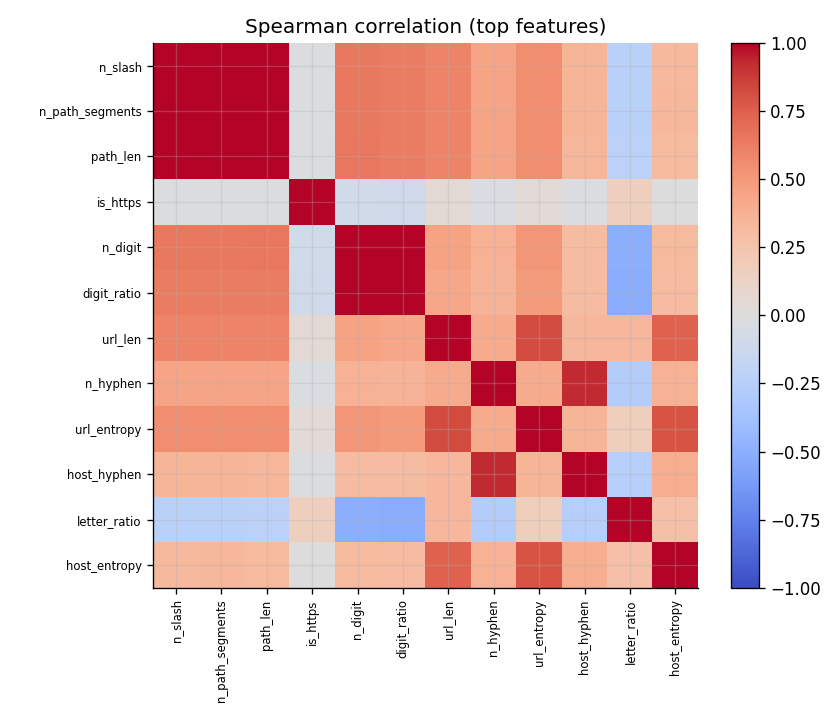

In [6]:
print("distribution shape (skewness / excess kurtosis):")
display(T("T6_eda_shape"))
print("correlation with the label (Pearson vs Spearman):")
display(T("T7_correlation"))
print("Mann-Whitney U — do the classes differ?")
display(T("T8_mannwhitney"))
F("F6_correlation")

Every key feature differs between classes at $p \ll 0.001$ — but that significance is exactly the
artifact: `is_https` has a near-perfect monotone correlation with the label, which no real-world phishing
signal should.

## 5. Models and *honest* evaluation

*Course link — train/val/test, the metric zoo, statistical validity.* Logistic regression, random forest
and histogram gradient boosting, chosen on validation F1. I never trust a point estimate: every headline
metric gets a **bootstrap 95% CI**, and every pairwise comparison a **McNemar test**. I report **MCC**
and **F2** (a missed phishing costs more than a false alarm), not just accuracy.

In [7]:
display(T("T2_model_comparison"))

,model,f1,f1_95ci,recall,precision,mcc,auc,mcnemar_vs_best
0,logreg,0.9942,"[0.993, 0.995]",0.9897,0.9988,0.9899,0.9980,p=7.7e-15
1,random_forest,0.9967,"[0.996, 0.997]",0.9944,0.9990,0.9942,0.9988,(best)
2,hist_gbm,0.9967,"[0.996, 0.997]",0.9941,0.9992,0.9942,0.9990,p=1.0e+00


The models are statistically indistinguishable and all near-perfect — again, because the task is artificially easy in-distribution.

## 6. What is the model actually using? (SHAP)

*Course link — explainability.* Tree models aren't linear, so I use **SHAP** (Lundberg & Lee, 2017) for
faithful per-feature attribution.

,feature,mean_abs_shap
0,is_https,0.205272
1,n_path_segments,0.069886
2,path_len,0.062445
3,n_slash,0.050001
4,n_digit,0.024564
5,url_len,0.021635
6,core_len,0.021029
7,digit_ratio,0.020223


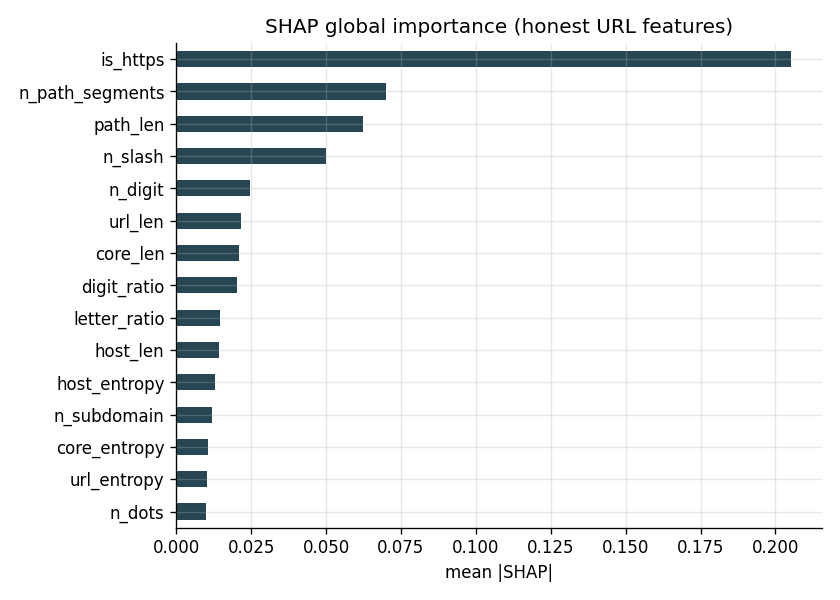

In [8]:
display(T("T5_shap_importance").head(8))
F("F5_shap")

The #1 driver is **`is_https`** by a factor of ~3, followed by path/structure features. The model is a
thin veneer over the collection artifact — which is precisely why the attacks in the next section work.

## 7. The arms race — attack the detector, then defend it

*Course link — adversarial ML: evasion, perturbation, homoglyphs, transferability, adversarial training.*
The attacker keeps the URL usable but shifts its surface toward "legitimate".

homoglyph        http://pаурal-verifу.acсouոt-ӏoɡіո.тк/webscr?cmd=login
typosquat        http://paypal-verify.aaccount-login.tk/webscr?cmd=login
https_upgrade    https://paypal-verify.account-login.tk/webscr?cmd=login
homepage_mimicry https://www.nqgqtjlzuz.org

recall on phishing under each attack / defense:


,attack,recall_attacked,recall_+normalize,recall_+debias(no https)
0,(clean),0.994,0.994,0.994
1,homoglyph,0.992,0.994,0.994
2,typosquat,0.993,0.993,0.994
3,https_upgrade,0.672,0.672,0.704
4,homepage_mimicry,0.000,0.000,0.000


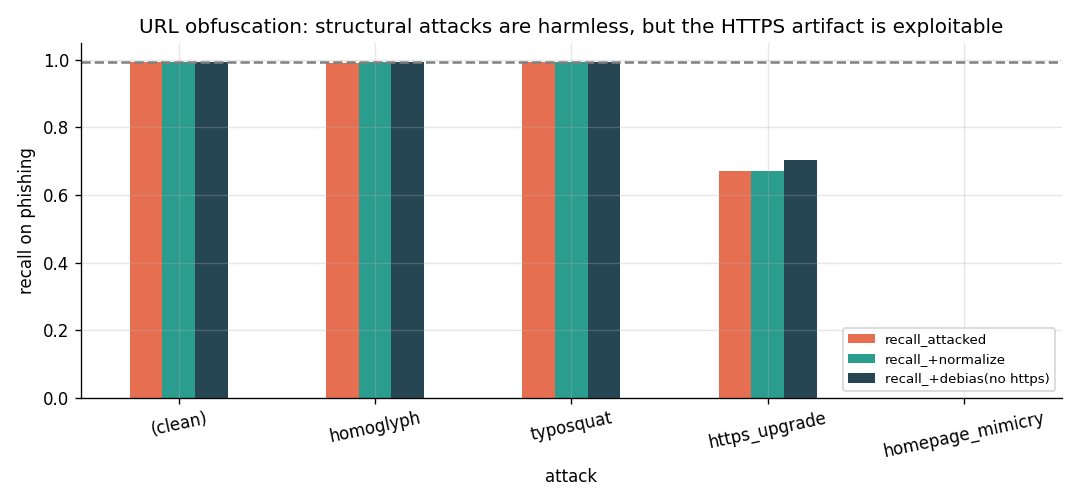

In [9]:
rng = np.random.default_rng(0)
u = "http://paypal-verify.account-login.tk/webscr?cmd=login"
for k, fn in attacks.ATTACKS.items():
    print(f"{k:16s} {fn(u, rng)}")
print("\nrecall on phishing under each attack / defense:")
display(T("T3_arms_race"))
F("F3_arms_race")

Two honest findings:
- **Structural attacks (homoglyph, typosquat) barely dent it** (0.99) — a *structural* URL detector is
  robust to the character tricks that *break* my partner's text model. A nice complementarity.
- **The artifact is the hole:** flipping HTTP→HTTPS drops recall to 0.67; full home-page mimicry drops
  it to **0.00**. Normalization (the homoglyph defense) correctly does nothing here, and dropping
  `is_https` barely helps — the bias is diffuse. There is no URL-only fix; the answer is a second signal.

## 8. An unsupervised angle — anomaly detection

*Course link — abnormality detection: Isolation Forest, Local Outlier Factor.* If phishing is "unusual",
can we catch it *without labels*, training only on legitimate URLs?

In [10]:
display(T("T10_anomaly"))

,unsupervised_detector,auc
0,IsolationForest,0.828
1,LocalOutlierFactor,0.944


Isolation Forest reaches AUC 0.83 and LOF 0.94 with **no phishing labels at all** — respectable, but well
below the supervised model, and still riding the same structural artifacts.

## 9. Are the probabilities trustworthy? (calibration)

*Course link — goodness of fit / calibration.*

,mean_predicted,observed_freq
0,0.003,0.003
1,0.141,0.293
2,0.234,0.273
3,0.340,0.500
4,0.449,0.250
5,0.560,0.500
6,0.634,0.556
7,0.745,0.364
8,0.850,0.958
9,1.000,1.000


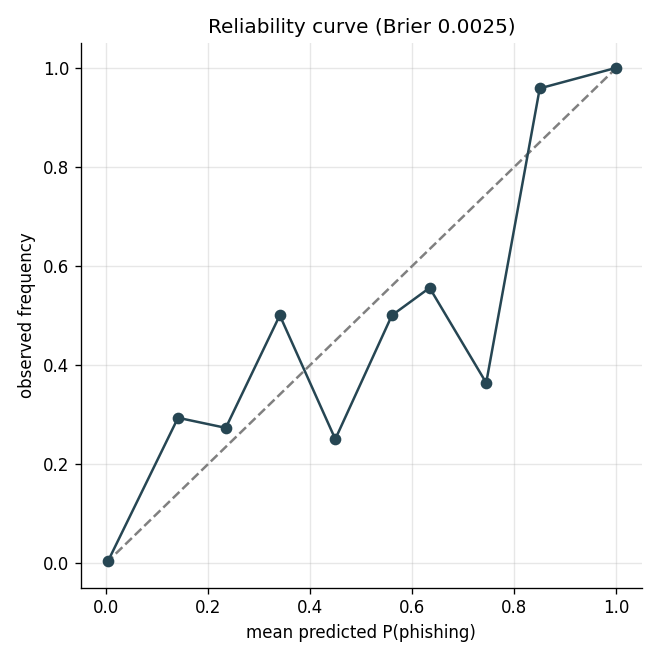

In [11]:
display(T("T11_calibration"))
F("F8_calibration")

In-distribution the model is very well calibrated (low Brier) — but as the next section shows, that calibration does **not** survive a change of dataset.

## 10. The reality check — cross-dataset generalization

*Course link — domain shift / concept drift, and distance metrics (KS, Wasserstein).* The real question:
does the score survive a **different** dataset? I test on the independent **Kaggle Malicious-URLs** set
(Siddhartha 2021, 651k URLs; phishing vs. benign), and on the **live OpenPhish** feed.

,setting,f1,recall_phishing,auc,threshold
0,in-distribution (PhiUSIIL test),0.997,0.994,0.999,0.50
1,"cross-dataset (Kaggle, full model)",0.666,0.999,0.434,0.50
2,"cross-dataset (Kaggle, no is_https)",0.666,0.998,0.168,0.50
3,"cross-dataset (Kaggle, re-thresholded)",0.667,1.000,0.434,0.01
4,live OpenPhish (recall only),NaN,1.000,NaN,0.50


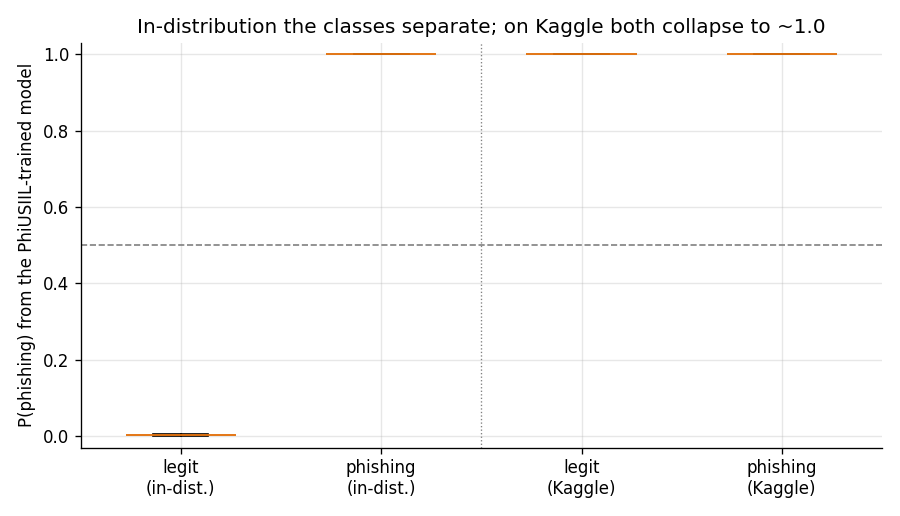

In [12]:
display(T("T4_cross_dataset"))
F("F4_cross_dataset")

The near-perfect model (in-dist F1 0.997, AUC 0.999) collapses to **F1 0.67 / AUC 0.43 — worse than
random**. The boxplot shows why: in-distribution the two classes are cleanly separated (legit near 0,
phishing near 1), but on the Kaggle set **both classes collapse to the same saturated region near 1.0**
(mean score 1.000 for benign, 0.999 for phishing — the model isn't just less confident, it can no longer
tell the classes apart at all). AUC < 0.5 means that within that saturated band, benign URLs score
*fractionally higher* than phishing on average — a true inversion, not just noise. Yet it still catches
**100% of live OpenPhish phishing**, because today's real phishing is *still* structurally messy.

*Why* does it invert? Distance metrics make it concrete — the most-shifted features between the two
datasets are exactly the ones the model relies on:

,feature,ks_statistic,wasserstein_norm
0,is_https,0.741,1.789
1,path_len,0.694,0.931
2,n_path_segments,0.627,1.915
3,n_subdomain,0.435,0.968
4,url_len,0.343,0.434
5,n_slash,0.309,1.060
6,letter_ratio,0.294,0.446
7,n_dots,0.280,0.559


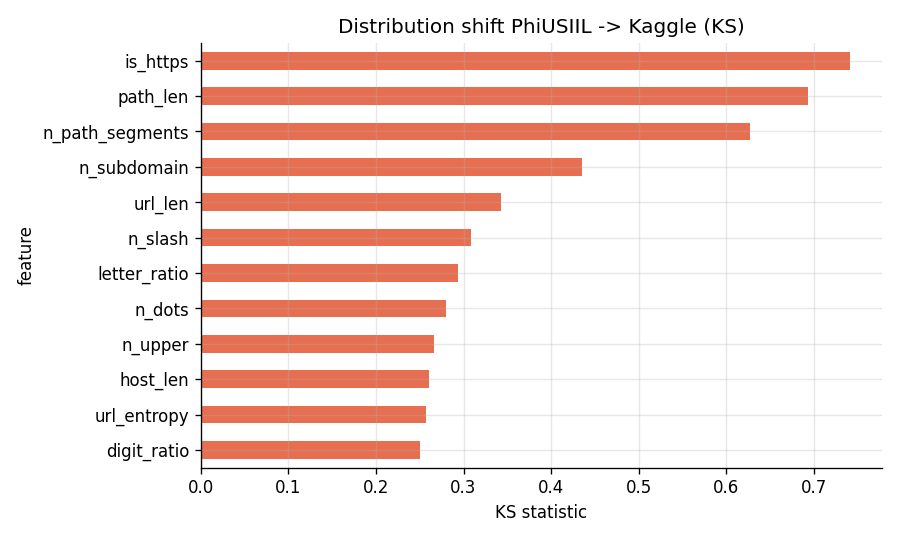

In [13]:
display(T("T9_domain_shift").head(8))
F("F7_domain_shift")

`is_https`, `path_len`, `n_subdomain` — the top SHAP drivers — are also the top KS-shifted features. The
model built its decision on the least transferable signals. This is the URL analogue of my partner's
cross-corpus collapse, but more severe (AUC below 0.5 vs her 0.78).

## 11. Feature ablation and error analysis

In [14]:
print("which feature groups carry the (in-distribution) signal:")
display(T("T12_ablation"))
print("errors on the clean test set:")
display(T("T13_error_counts"))
display(T("T13b_error_examples"))

which feature groups carry the (in-distribution) signal:


,feature_group,n_features,f1,auc
0,length/counts,8,0.993,0.998
1,host/domain,5,0.687,0.823
2,tld,2,0.266,0.574
3,entropy,3,0.806,0.928
4,scheme/encoding,4,0.696,0.767
5,brand/cue,5,0.273,0.582


errors on the clean test set:


,item,count
0,false_positive,15
1,false_negative,119
2,test_size,47074


,type,URL,y,p
0,FP,https://www.180360.com,0,0.876
1,FP,https://www.betterplants.basf.us,0,0.706
2,FP,https://www.10000birds.com,0,0.561
3,FP,https://www.thefeedbackloop.xyz,0,0.733
4,FP,https://www.provincialarchives.alberta.ca,0,0.746
5,FN,https://what.promerc.repl.co,1,0.011
6,FN,https://s.smcbacmzu.icu,1,0.103
7,FN,https://www.microsoft-sicherheitsupdate.com,1,0.108
8,FN,https://www.nailcanhillrun.com.au,1,0.003
9,FN,https://www.2023foco.com.br,1,0.015


The `scheme/encoding` group (which is basically `is_https`) alone nearly matches the full model — the
ablation confirms the artifact. On clean data the model makes very few errors, all borderline; the danger
is not clean-data mistakes but the obfuscation and domain-shift failures above.

## 12. Conclusions

**What I built:** a fast, interpretable, URL-only phishing detector, and an honest audit of it.

**What I found:**
1. The near-perfect public benchmark (F1 1.0) is a **collection artifact** — one leaked feature, and
   HTTP-vs-HTTPS. SHAP and the ablation both pin it on `is_https`.
2. A structural detector is **robust to homoglyph/typo tricks** (unlike a text model) but is **evaded by
   home-page mimicry** (recall → 0).
3. It **does not generalize**: on an independent dataset it drops to **AUC 0.43**, and distance metrics
   show why — the features it trusts are the ones that shift most.
4. It still catches **current** real phishing (OpenPhish recall 1.0), so it is useful *today* as one
   layer — but a brittle one.

**The headline:** URL structure alone is not a generalizable phishing signal. The right use is as an
**independent channel fused with content** (my partner's half) and with non-lexical signals (domain age,
reputation) — so that when an attacker defeats one channel, another still fires.

### Course concepts used, and where
| Concept | Where |
|---|---|
| EDA, distributions, skewness/kurtosis, robust statistics | §1, §4 |
| Correlation: Pearson vs Spearman; Mann–Whitney U | §4 |
| Feature engineering; Shannon entropy; Levenshtein edit distance | §2 |
| Accuracy paradox; Precision/Recall/F1/**F2**/**MCC**/AUC; cost-sensitive threshold | §3, §5 |
| Statistical validity: bootstrap CIs, McNemar | §5 |
| Explainability (SHAP) | §6 |
| Adversarial ML: evasion, perturbation, homoglyphs, transferability, adversarial training | §7 |
| Anomaly detection: Isolation Forest, LOF | §8 |
| Calibration / goodness of fit | §9 |
| Domain shift / concept drift; **distance metrics (KS, Wasserstein/EMD)** | §10 |
| Dimensionality via feature-group ablation; error analysis | §11 |

**Limitations & future work:** the cross-dataset comparison is affected by differing URL encodings
(schemes) — I control for it with the no-`is_https` variant, which is *worse*, confirming the bias is
diffuse. Next: WHOIS/domain-age and redirect-chain features, a live-feed retraining loop, and the
**fusion** with the content detector (deliberately out of scope for this half).

*References:* Prasad & Chandra 2024 (PhiUSIIL); Siddhartha 2021 (Kaggle Malicious URLs); OpenPhish;
Majestic Million; Ma et al. 2009; Garera et al. 2007; Sahingoz et al. 2019; Le et al. 2018 (URLNet);
Boucher et al. 2022 (Bad Characters); Lundberg & Lee 2017 (SHAP); Unicode TR39 (confusables).